# Least squares: solve a four-pixel disagreement

How can one surface approximate neighbor differences that disagree around a loop?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

Label a square in row-major order $A,B,D,C$. Orient its edges $A\to B$,
$B\to C$, $D\to C$, $A\to D$. Each row of $D$ contains $-1$ at the tail
and $+1$ at the head. Thus $Du$ is the vector of ordinary phase differences.

Take $w/\pi=(0,0.6,-0.2,-0.8)$. Wrapping each difference gives
$g/\pi=(0.6,0.6,-0.6,-0.2)$, and the clockwise sum is $2\pi$.
No $u$ satisfies all four measurements exactly.

1. Form residuals $e=Du-g$.
2. Minimize $J=e^Te$; differentiate: $\nabla J=2D^T(Du-g)$.
3. Solve $D^TDu=D^Tg$ with $\sum u=0$ to fix the nullspace.

$D^TD$ is the **positive graph Laplacian**, corresponding to minus the usual
continuous Laplacian. With divergence $=-D^T$, the equivalent Poisson form is
$\Delta u=\operatorname{div}g$. Keeping the signs consistent avoids a common mistake.

| Edge | Measured / π | Fitted / π | Residual / π |
|---|---|---|---|
| AB | 0.60 | 0.10 | -0.50 |
| BC | 0.60 | 0.10 | -0.50 |
| DC | -0.60 | -0.10 | 0.50 |
| AD | -0.20 | 0.30 | 0.50 |

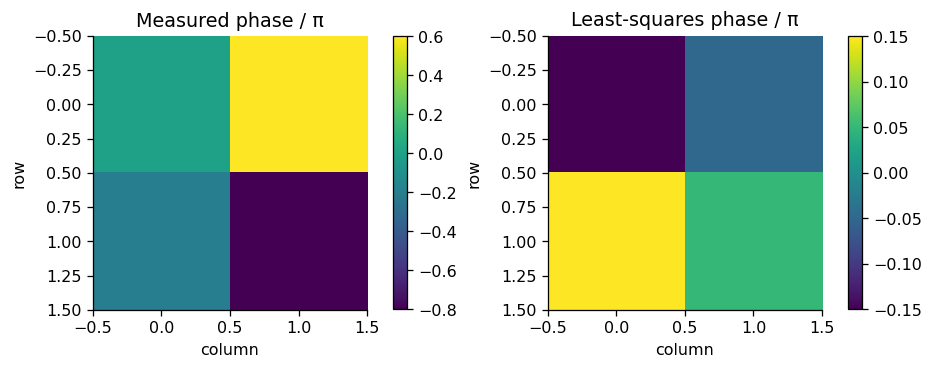

In [2]:
D=np.array([[-1,1,0,0],[0,-1,0,1],[0,0,-1,1],[-1,0,1,0]],float)
w=np.pi*np.array([0,.6,-.2,-.8]); g=W(D@w)
u=np.linalg.lstsq(np.vstack([D,np.ones(4)]),np.r_[g,0],rcond=None)[0]
table(['Edge','Measured / π','Fitted / π','Residual / π'],
      [(e,f'{a/np.pi:.2f}',f'{b/np.pi:.2f}',f'{(b-a)/np.pi:.2f}')
       for e,a,b in zip(['AB','BC','DC','AD'],g,D@u)])
assert np.allclose(D.T@(D@u-g),0)
images([w.reshape(2,2)/np.pi,u.reshape(2,2)/np.pi],['Measured phase / π','Least-squares phase / π'])

## 2 · Read the calculation

The fitted clockwise differences close exactly, while the residual distributes
the one-turn conflict among the four edges. A least-squares surface need not wrap
back to the measured phase. It minimizes gradient residuals over real values,
not integer pixel labels. With no residues and no aliased steps, integration can
fit the noisy phase itself exactly; least squares is not automatically a denoiser.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

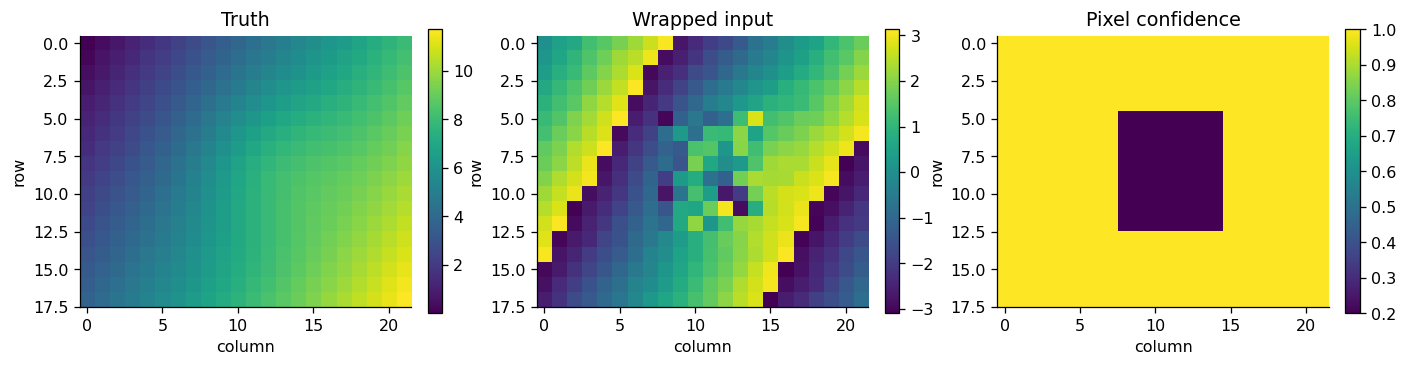

Info(backend='numpy', iterations=1, relative_residual=1.9452306645690367e-15, converged=True)


| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.492851 |
| Raw max wrapped difference from input (rad) | 3.022210 |

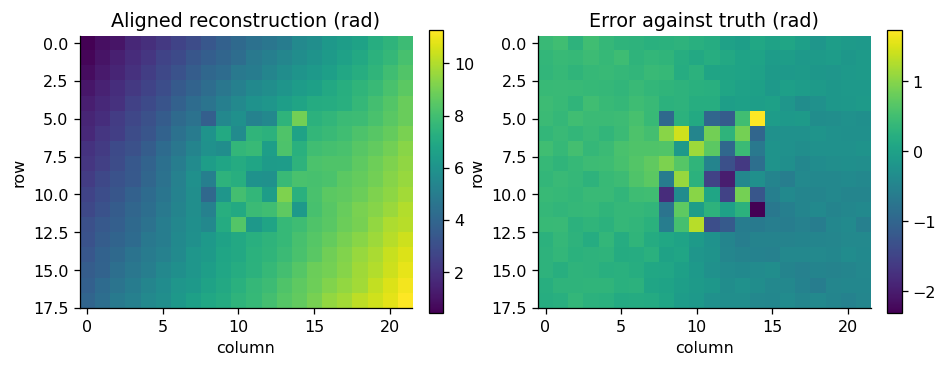

In [3]:
truth,phase,confidence=scene()
images([truth,phase,confidence],['Truth','Wrapped input','Pixel confidence'])
result,info=pv.unwrap(phase,return_info=True)
print(info); report(result,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

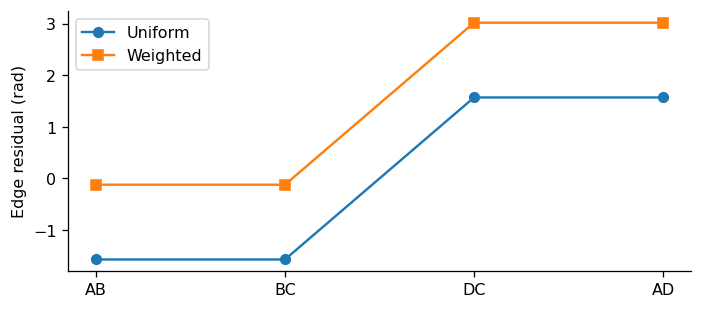

Info(backend='numpy', iterations=13, relative_residual=2.969763967410029e-09, converged=True)
Weighted aligned RMSE: 0.35025069137791853


In [4]:
# Parvaneh SQUARES pixel weights, then takes the minimum at each edge.
pixel_weight=np.array([1.,1.,.2,1.])
ends=[(0,1),(1,3),(2,3),(0,2)]
q=np.array([min(pixel_weight[a]**2,pixel_weight[b]**2) for a,b in ends])
weighted=np.linalg.lstsq(np.vstack([np.sqrt(q)[:,None]*D,np.ones(4)]),
                        np.r_[np.sqrt(q)*g,0],rcond=None)[0]
actual=pv.unwrap(w.reshape(2,2),pixel_weight.reshape(2,2),tol=1e-10)
assert np.allclose(actual.ravel(),weighted,atol=1e-7)
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(D@u-g,'o-',label='Uniform'); ax.plot(D@weighted-g,'s-',label='Weighted')
ax.set(xticks=range(4),xticklabels=['AB','BC','DC','AD'],ylabel='Edge residual (rad)')
ax.legend(); plt.show()
weighted_large,wi=pv.unwrap(phase,confidence,return_info=True)
print(wi); print('Weighted aligned RMSE:',pv.rmse_aligned(weighted_large,truth))

## 5 · Interpretation and limits

For this API $q_{ab}=\min(c_a^2,c_b^2)$, not simply $c_a$.
The weighted equation is $D^TQD u=D^TQg$. Low-cost edges can absorb more
inconsistency, but low cost does not identify the correct physical jump.
Positive weights keep this small grid connected; zero weights may create
independent components with independent offsets. Replace nonfinite input with
finite placeholders before supplying zero weights.

`unwrap` supports any rank with every axis at least length two. DCT diagonalizes
the unweighted rectangular-grid operator; weighted problems use it as a
preconditioner in conjugate gradients. Accelerated backends are implementations
of the same method, not separate mathematical algorithms.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`core.py`](../src/parvaneh/core.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.